### Implement multi layer perceptron (MLP) -- character level language model. 

[referenece video](https://www.youtube.com/watch?v=TCH_1BHY58I)

In [264]:
import torch
import torch.nn as nn
from torch.nn import functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [265]:
# read all words
words = open('names.txt').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [266]:
len(words)

32033

In [267]:
# build the vocabulary of characters and mapping to/from integers

chars = sorted(list(set(''.join(words))))
stoi = { ch: i for i, ch in enumerate(chars) }
stoi['.'] = 0
itos = { i: ch for ch, i in stoi.items() }
print(itos)

{0: '.', 1: 'b', 2: 'c', 3: 'd', 4: 'e', 5: 'f', 6: 'g', 7: 'h', 8: 'i', 9: 'j', 10: 'k', 11: 'l', 12: 'm', 13: 'n', 14: 'o', 15: 'p', 16: 'q', 17: 'r', 18: 's', 19: 't', 20: 'u', 21: 'v', 22: 'w', 23: 'x', 24: 'y', 25: 'z'}


In [268]:
# build the dataset

block_size = 3  # context lenght of how many characters to consider to predict the next one
X, Y = [], []

for w in words[:5]:
    print(w)
    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        print(''.join(itos[i] for i in context), '--> ', itos[ix])
        context = context[1:] + [ix]

X = torch.tensor(X)
Y = torch.tensor(Y) 



emma
... -->  e
..e -->  m
.em -->  m
emm -->  .
mm. -->  .
olivia
... -->  o
..o -->  l
.ol -->  i
oli -->  v
liv -->  i
ivi -->  .
vi. -->  .
ava
... -->  .
... -->  v
..v -->  .
.v. -->  .
isabella
... -->  i
..i -->  s
.is -->  .
is. -->  b
s.b -->  e
.be -->  l
bel -->  l
ell -->  .
ll. -->  .
sophia
... -->  s
..s -->  o
.so -->  p
sop -->  h
oph -->  i
phi -->  .
hi. -->  .


In [269]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([32, 3]), torch.int64, torch.Size([32]), torch.int64)

In [270]:
X

tensor([[ 0,  0,  0],
        [ 0,  0,  4],
        [ 0,  4, 12],
        [ 4, 12, 12],
        [12, 12,  0],
        [ 0,  0,  0],
        [ 0,  0, 14],
        [ 0, 14, 11],
        [14, 11,  8],
        [11,  8, 21],
        [ 8, 21,  8],
        [21,  8,  0],
        [ 0,  0,  0],
        [ 0,  0,  0],
        [ 0,  0, 21],
        [ 0, 21,  0],
        [ 0,  0,  0],
        [ 0,  0,  8],
        [ 0,  8, 18],
        [ 8, 18,  0],
        [18,  0,  1],
        [ 0,  1,  4],
        [ 1,  4, 11],
        [ 4, 11, 11],
        [11, 11,  0],
        [ 0,  0,  0],
        [ 0,  0, 18],
        [ 0, 18, 14],
        [18, 14, 15],
        [14, 15,  7],
        [15,  7,  8],
        [ 7,  8,  0]])

In [271]:
# embedding lookup table 'C'
# 27 possible characters, lets try putting them in 2D lookup table

C = torch.randn((27, 2))

C[5]

tensor([ 2.7604, -0.0714])

In [272]:
# embedding lookup using one_hot

F.one_hot(torch.tensor(5), num_classes=27).float() @ C
# this will result in error as F.dtype is float32



tensor([ 2.7604, -0.0714])

In [273]:
# pytorch indexing is flexible. we can do with list, tensor of integers, we can repeat rows too
print(C[[5, 6, 7]] == C[torch.tensor([5,6,7])])

C[torch.tensor([5,6,7, 7, 7, 7])]

tensor([[True, True],
        [True, True],
        [True, True]])


tensor([[ 2.7604, -0.0714],
        [-0.7170,  0.3421],
        [ 0.8874,  0.0229],
        [ 0.8874,  0.0229],
        [ 0.8874,  0.0229],
        [ 0.8874,  0.0229]])

In [274]:
emb = C[X]
emb.shape

torch.Size([32, 3, 2])

In [275]:
# weights and biases
w1 = torch.randn((6, 100))
b1 = torch.randn((100,))

In [276]:
# linear layer
#emb @ w1 + b1
# this will not work as emb = torch.size([32, 3, 2]) and w1 = torch.size([6, 100])  so we need to reshape emb
# Ww need to contact the last two dimensions of emb to make it compatible with w1

# ways to concat

print("before concat")
print("emb[0] ->", emb[0])
print("emb.shape ->", emb.shape)

torch_concat_emb = torch.cat([emb[:, 0, :], emb[:, 1, :], emb[:, 2, :]], 1)
print("\nafter concat on first dimention")
print("emb[0] ->", torch_concat_emb[0])
print("emb.shape ->", torch_concat_emb.shape)

# torch.unwind
print("\nafter concat using torch.unbind")
torch_unwind_emb = torch.cat(torch.unbind(emb, 1), 1)
print("emb[0] ->", torch_unwind_emb[0])
print("emb.shape ->", torch_unwind_emb.shape)

# thorch.view
print("\nafter concat using torch.view")
torch_view_emb = emb.view(32, 6)
print("emb[0] ->", torch_view_emb[0])
print("emb.shape ->", torch_view_emb.shape)

print("\n\nall contcats equal ->", torch.equal(torch_view_emb, torch_unwind_emb) and torch.equal(torch_unwind_emb, torch_concat_emb))


# torch.view is the most efficient method to concat due to how tensor is stored in memory.
# In view method, we are not creating new tensor, we are just changing the view of the tensor.
# So, it is the most efficient way to concat tensors.
 
# This can be verified by calling .storage() on tensor which is the underlying storage of the tensor.
# View changes other attributes of tensor like shape, strides, offset etc but not the storage.

# more info on this -http://blog.ezyang.com/2019/05/pytorch-internals/


before concat
emb[0] -> tensor([[ 0.9248, -0.3442],
        [ 0.9248, -0.3442],
        [ 0.9248, -0.3442]])
emb.shape -> torch.Size([32, 3, 2])

after concat on first dimention
emb[0] -> tensor([ 0.9248, -0.3442,  0.9248, -0.3442,  0.9248, -0.3442])
emb.shape -> torch.Size([32, 6])

after concat using torch.unbind
emb[0] -> tensor([ 0.9248, -0.3442,  0.9248, -0.3442,  0.9248, -0.3442])
emb.shape -> torch.Size([32, 6])

after concat using torch.view
emb[0] -> tensor([ 0.9248, -0.3442,  0.9248, -0.3442,  0.9248, -0.3442])
emb.shape -> torch.Size([32, 6])


all contcats equal -> True


In [277]:
h = torch.tanh(emb.view(-1, 6) @ w1 + b1)

h

tensor([[ 0.8046, -0.9316,  0.7759,  ..., -0.1091,  0.9536, -0.9946],
        [ 0.9235, -0.2468, -0.8231,  ..., -0.6949,  1.0000, -0.9995],
        [ 0.7359,  0.9766,  0.6003,  ..., -0.6377,  0.2381, -0.5528],
        ...,
        [-0.9495, -0.9747,  0.9948,  ...,  0.8915,  0.6463, -0.9421],
        [ 0.8534, -0.9894,  0.1007,  ...,  0.3264,  1.0000, -0.9992],
        [-0.9789,  0.5855,  0.9907,  ...,  0.4392, -0.0842, -0.8961]])

In [278]:
w2 = torch.randn((100, 27))
b2 = torch.randn((27,))

In [279]:
logits = h @ w2 + b2
logits.shape

torch.Size([32, 27])

In [280]:
counts = logits.exp()

In [281]:
prob = counts / counts.sum(dim=1, keepdim=True) # softmax

prob.shape

torch.Size([32, 27])

In [282]:
loss = -prob[torch.arange(32), Y].log().mean()

In [283]:
# -------- summarizing and cleaning code -------------- #

In [284]:
X, Y = [], []
block_size = 3  # context lenght of how many characters to consider to predict the next one

for w in words:
    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        context = context[1:] + [ix]

X = torch.tensor(X)
Y = torch.tensor(Y) 
X.shape, Y.shape # dataset

(torch.Size([228146, 3]), torch.Size([228146]))

In [285]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 2), generator=g)
w1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g)
w2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, w1, b1, w2, b2]

In [286]:
sum(p.nelement() for p in parameters)

3481

In [287]:
for p in parameters:
    # p.requires_grad = True
    p.requires_grad_()

In [288]:
# training loop

for _ in range(10):
    # forward pass
    emb = C[X]
    h = torch.tanh(emb.view(-1, 6) @ w1 + b1)
    logits = h @ w2 + b2

    # three lines below can be replaced by F.cross_entropy which is much more efficient due to pytorch implementation
    # counts = logits.exp()
    # prob = counts / counts.sum(dim=1, keepdim=True) # softmax
    # loss = -prob[torch.arange(32), Y].log().mean()
    loss = F.cross_entropy(logits, Y)
    print(loss.item())

    #backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    for p in parameters:
        p.data -= p.grad * 0.1

19.646800994873047
16.503475189208984
15.109922409057617
14.053929328918457
13.236257553100586
12.64303207397461
12.114055633544922
11.634844779968262
11.203010559082031
10.811844825744629


In [289]:
# when we process full dataset we have 220k samples instead of 32 previously.
# we are doing way too much work forwarding and backwarding on 220k dataset. 
# we can do this in minibatches and optimize the iteration.

for _ in range(10):
    # minibatching
    ix = torch.randint(0, X.shape[0], (32,))
    # forward pass
    emb = C[X[ix]] # 32 x 3 x 2
    h = torch.tanh(emb.view(-1, 6) @ w1 + b1)
    logits = h @ w2 + b2

    # three lines below can be replaced by F.cross_entropy which is much more efficient due to pytorch implementation
    # counts = logits.exp()
    # prob = counts / counts.sum(dim=1, keepdim=True) # softmax
    # loss = -prob[torch.arange(32), Y].log().mean()
    loss = F.cross_entropy(logits, Y[ix])
    print(loss.item())

    #backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    for p in parameters:
        p.data -= p.grad * 0.1 # learning rate 0.1


# here we are not interating over all 220k but on 32 samples in minibatch.
# due to this quality of grandiant discent is lower and is not as reliable.
# But its good enough and worthy tradeoff for speed. 


13.184488296508789
8.316949844360352
9.008056640625
6.944538593292236
6.974998474121094
9.150594711303711
10.36029052734375
9.216967582702637
8.046961784362793
8.38394546508789


In [290]:
# current learning rate is 0.1, how do we validate or caulate the correct learning rate?

lre = torch.linspace(-3, 0, 1000 )
lrs = 10**lre # 0.001 to 1

In [291]:
lri = []
lossi = []

In [292]:
for i in range(1000):
    # minibatching
    ix = torch.randint(0, X.shape[0], (32,))
    # forward pass
    emb = C[X[ix]] # 32 x 3 x 2
    h = torch.tanh(emb.view(-1, 6) @ w1 + b1)
    logits = h @ w2 + b2

    # three lines below can be replaced by F.cross_entropy which is much more efficient due to pytorch implementation
    # counts = logits.exp()
    # prob = counts / counts.sum(dim=1, keepdim=True) # softmax
    # loss = -prob[torch.arange(32), Y].log().mean()
    loss = F.cross_entropy(logits, Y[ix])
    print(loss.item())

    #backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = lrs[i]
    for p in parameters:
        p.data += p.grad * -lr # learning rate
    
    lri.append(lre[i])
    lossi.append(loss.item())


7.703564643859863
8.941686630249023
8.178579330444336
8.335880279541016
6.657350540161133
5.764868259429932
7.489932537078857
8.877469062805176
7.785022258758545
6.363193511962891
7.941468238830566
7.435521125793457
10.685713768005371
6.756795406341553
8.526744842529297
9.958642959594727
7.076785087585449
9.085808753967285
7.462331771850586
7.27555513381958
6.051191329956055
7.415383338928223
7.254603862762451
9.969508171081543
8.079148292541504
7.71834135055542
7.937388896942139
5.2793474197387695
6.593277931213379
7.046223163604736
7.325586318969727
8.731949806213379
7.758655548095703
7.086007595062256
7.41094970703125
9.569292068481445
8.900811195373535
8.503538131713867
8.26547622680664
6.736024856567383
8.516243934631348
7.386516571044922
6.439146995544434
6.825838565826416
6.7901177406311035
8.290369033813477
7.5232062339782715
8.260869026184082
7.082383155822754
9.245123863220215
8.349563598632812
7.83131217956543
7.554861068725586
8.999858856201172
8.912911415100098
7.380675315

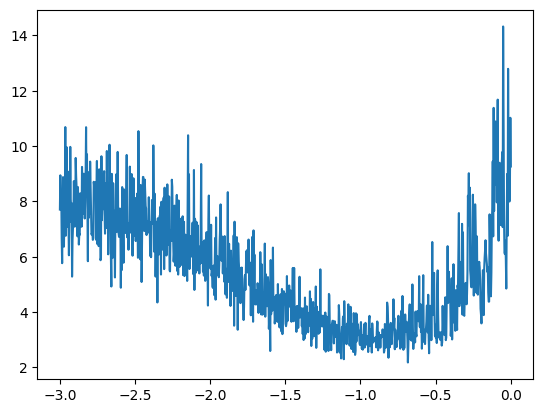

In [293]:
plt.plot(lri, lossi)

In [294]:
# learning rate decay.
# after training for the model, at the end, we do a learning rate delay for be